### EN3160 Assignment 01
**Intensity Transformations and Neighborhood Filtering**  
**Rahman MFA | 230507R**  
[GitHub Repository](https://github.com/Abdul-Rahman-bme/EN3160-Image-processing-and-Machine-Vision)

In [2]:
import cv2 as cv, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
IMAGE_DIR, OUTPUT_DIR = Path("images"), Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

### Q1 — Piecewise Intensity Transformation

A piecewise-linear intensity transformation was applied using selected breakpoints to expand the mid-intensity range and improve contrast.

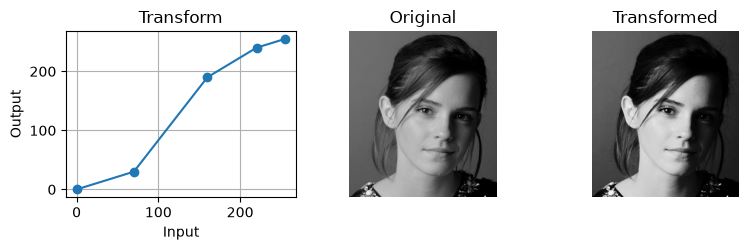

In [3]:
def intensity_transform(im, points):
    lut = np.zeros(256, dtype=np.uint8)
    for i in range(len(points)-1):
        x1, y1 = points[i]
        x2, y2 = points[i+1]
        slope = (y2-y1)/(x2-x1)
        for x in range(int(x1), int(x2)+1):
            lut[x] = y1 + slope*(x-x1)
    return cv.LUT(im, lut)

img_q1=cv.imread(str(IMAGE_DIR/"q1_portrait.png"),cv.IMREAD_GRAYSCALE)
bp=np.array([[0,0],[70,30],[160,190],[220,240],[255,255]],dtype=np.float32)
q1_out=intensity_transform(img_q1,bp)

fig,ax=plt.subplots(1,3,figsize=(8,2.6))
ax[0].plot(bp[:,0],bp[:,1],'-o'); ax[0].set_title("Transform"); ax[0].set_xlabel("Input"); ax[0].set_ylabel("Output"); ax[0].grid()
ax[1].imshow(img_q1,cmap="gray",vmin=0,vmax=255); ax[1].set_title("Original")
ax[2].imshow(q1_out,cmap="gray",vmin=0,vmax=255); ax[2].set_title("Transformed")
for a in ax[1:]: a.axis("off")
plt.tight_layout(); plt.show()

**Discussion:** The transformation increases the contrast of the mid-intensity regions, making facial and hair details more distinct while keeping the output within the valid 8-bit range.

#### Q2 — White and Gray Matter Enhancement

Two piecewise-linear intensity transformations were designed to emphasize
different tissue intensity ranges in the brain proton-density image.

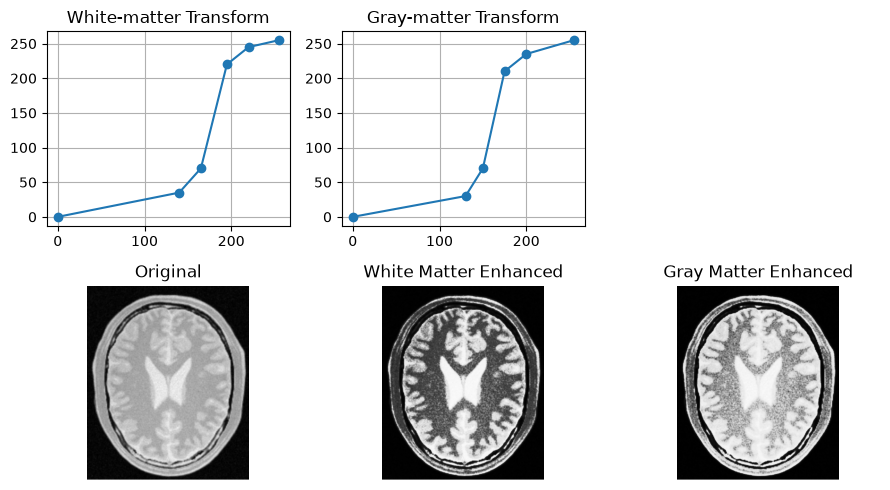

In [4]:
img_q2 = cv.imread(str(IMAGE_DIR/"q2_brain.png"), cv.IMREAD_GRAYSCALE)

white_points = np.array([
    [0,0], [140,35], [165,70], [195,220], [220,245], [255,255]
], dtype=np.float32)

gray_points = np.array([
    [0,0], [130,30], [150,70], [175,210], [200,235], [255,255]
], dtype=np.float32)

white_enh = intensity_transform(img_q2, white_points)
gray_enh  = intensity_transform(img_q2, gray_points)

fig,ax = plt.subplots(2,3,figsize=(9,5))

ax[0,0].plot(white_points
[:,0], white_points[:,1], '-o')
ax[0,0].set_title("White-matter Transform"); ax[0,0].grid()

ax[0,1].plot(gray_points[:,0], gray_points[:,1], '-o')
ax[0,1].set_title("Gray-matter Transform"); ax[0,1].grid()

ax[0,2].axis("off")

ax[1,0].imshow(img_q2,cmap="gray",vmin=0,vmax=255)
ax[1,0].set_title("Original")

ax[1,1].imshow(white_enh,cmap="gray",vmin=0,vmax=255)
ax[1,1].set_title("White Matter Enhanced")

ax[1,2].imshow(gray_enh,cmap="gray",vmin=0,vmax=255)
ax[1,2].set_title("Gray Matter Enhanced")

for a in ax[1]:
    a.axis("off")

plt.tight_layout()
plt.show()

**Discussion:** The two mappings expand different intensity ranges. The first
mapping gives stronger contrast to the selected higher-intensity tissue range,
while the second shifts the strongest enhancement toward a slightly lower
range. This allows different tissue regions to be emphasized separately rather
than simply increasing the overall brightness.

#### Q3 — Gamma Correction

Gamma correction was applied only to the lightness channel of the image in the
Lab color space so that brightness could be adjusted without directly changing
the color channels.

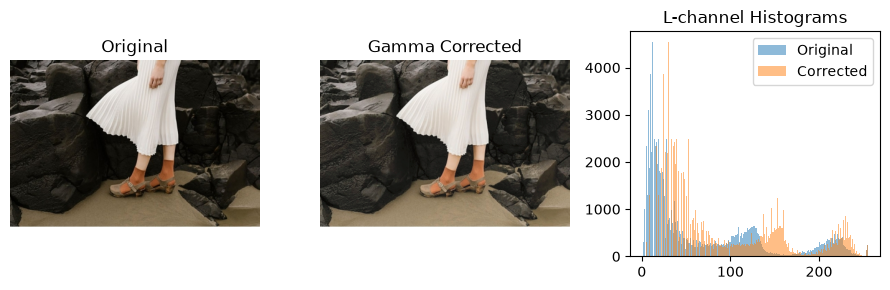

In [5]:
img_q3 = cv.imread(str(IMAGE_DIR/"q3_gamma.png"))
lab = cv.cvtColor(img_q3, cv.COLOR_BGR2LAB)
L, A_channel, B_channel = cv.split(lab)

gamma = 0.7
L_new = np.clip(255*(L/255.0)**gamma, 0, 255).astype(np.uint8)

out_q3 = cv.cvtColor(cv.merge([L_new,A_channel,B_channel]), cv.COLOR_LAB2RGB)

fig,ax = plt.subplots(1,3,figsize=(9,3))

ax[0].imshow(cv.cvtColor(img_q3,cv.COLOR_BGR2RGB))
ax[0].set_title("Original")

ax[1].imshow(out_q3)
ax[1].set_title("Gamma Corrected")

ax[2].hist(L.ravel(),bins=256, range=(0,256),alpha=0.5,label="Original")
ax[2].hist(L_new.ravel(),bins=256, range=(0,256),alpha=0.5,label="Corrected")
ax[2].set_title("L-channel Histograms")
ax[2].legend()

for a1 in ax[:2]:
    a1.axis("off")

plt.tight_layout()
plt.show()

### Selecting the Gamma Value

Several gamma values were tested before selecting the final value. Values below
1 brighten the image, while values above 1 darken it.

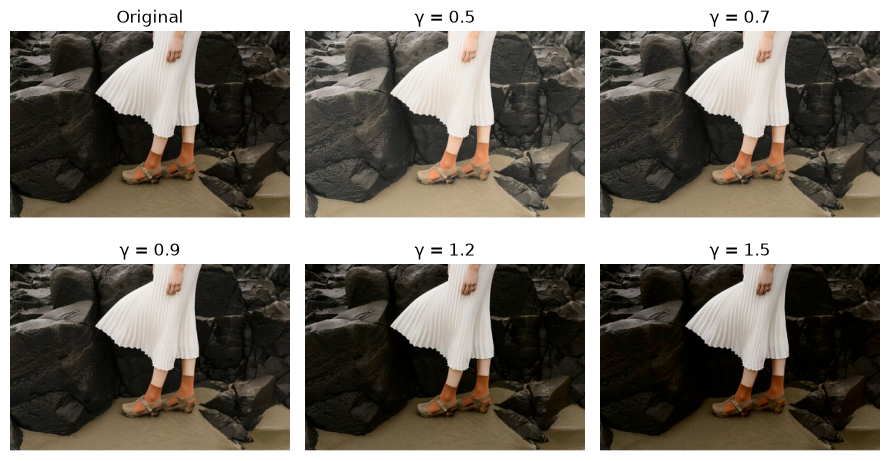

In [6]:
img_q3 = cv.imread(str(IMAGE_DIR/"q3_gamma.png"))

lab = cv.cvtColor(img_q3, cv.COLOR_BGR2LAB)
L, A_lab, B_lab = cv.split(lab)

gamma_values = [0.5, 0.7, 0.9, 1.2, 1.5]

fig,ax = plt.subplots(2,3,figsize=(9,5))

ax[0,0].imshow(cv.cvtColor(img_q3,cv.COLOR_BGR2RGB))
ax[0,0].set_title("Original")
ax[0,0].axis("off")

for i,g in enumerate(gamma_values):
    Lt = np.clip(255*(L/255.0)**g,0,255).astype(np.uint8)

    test = cv.cvtColor(
        cv.merge([Lt, A_lab, B_lab]),
        cv.COLOR_LAB2RGB
    )

    ax.ravel()[i+1].imshow(test)
    ax.ravel()[i+1].set_title(f"γ = {g}")
    ax.ravel()[i+1].axis("off")

plt.tight_layout()
plt.show()

**Discussion:** A gamma value of 0.7 was selected because it brightened the dark
and mid-level regions while keeping the brighter areas reasonably controlled.
The correction was applied only to the L channel, so the a and b color channels
were not directly modified.
For \(\gamma<1\), dark and mid-level intensities are increased,
while \(\gamma>1\) makes the image darker. Among the tested values,
\(\gamma=0.7\) gave a useful improvement in the darker rock regions without
making the bright parts of the image excessively strong. Therefore,
\(\gamma=0.7\) was selected for the final correction.

#### Q4 — Vibrance Enhancement

The saturation channel of the HSV image was modified using the given
vibrance transformation. Several values of the parameter \(a\) were tested,
and \(a=0.6\) was selected for the final result.

In [7]:
def vibrance_transform(S, strength, sigma=70):

    S = S.astype(np.float32)

    boost = strength*128*np.exp(
        -((S-128)**2)/(2*sigma**2)
    )

    return np.clip(S+boost,0,255).astype(np.uint8)

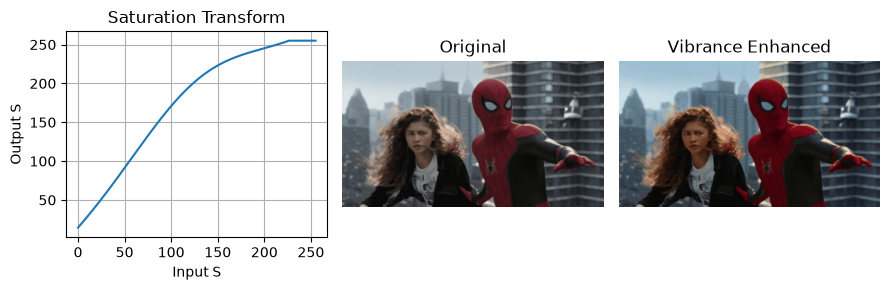

In [8]:

img_q4 = cv.imread(str(IMAGE_DIR/"q4_vibrance.png"))
hsv = cv.cvtColor(img_q4, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

a, sigma = 0.6, 70
S_new = vibrance_transform(S, a)

out_q4 = cv.cvtColor(cv.merge([H,S_new,V]), cv.COLOR_HSV2RGB)

x = np.arange(256)
y = np.clip(x + a*128*np.exp(-((x-128)**2)/(2*sigma**2)),0,255)

fig,ax = plt.subplots(1,3,figsize=(9,3))

ax[0].plot(x,y)
ax[0].set_title("Saturation Transform")
ax[0].set_xlabel("Input S")
ax[0].set_ylabel("Output S")
ax[0].grid()

ax[1].imshow(cv.cvtColor(img_q4,cv.COLOR_BGR2RGB))
ax[1].set_title("Original")

ax[2].imshow(out_q4)
ax[2].set_title("Vibrance Enhanced")

for a1 in ax[1:]:
    a1.axis("off")

plt.tight_layout()
plt.show()

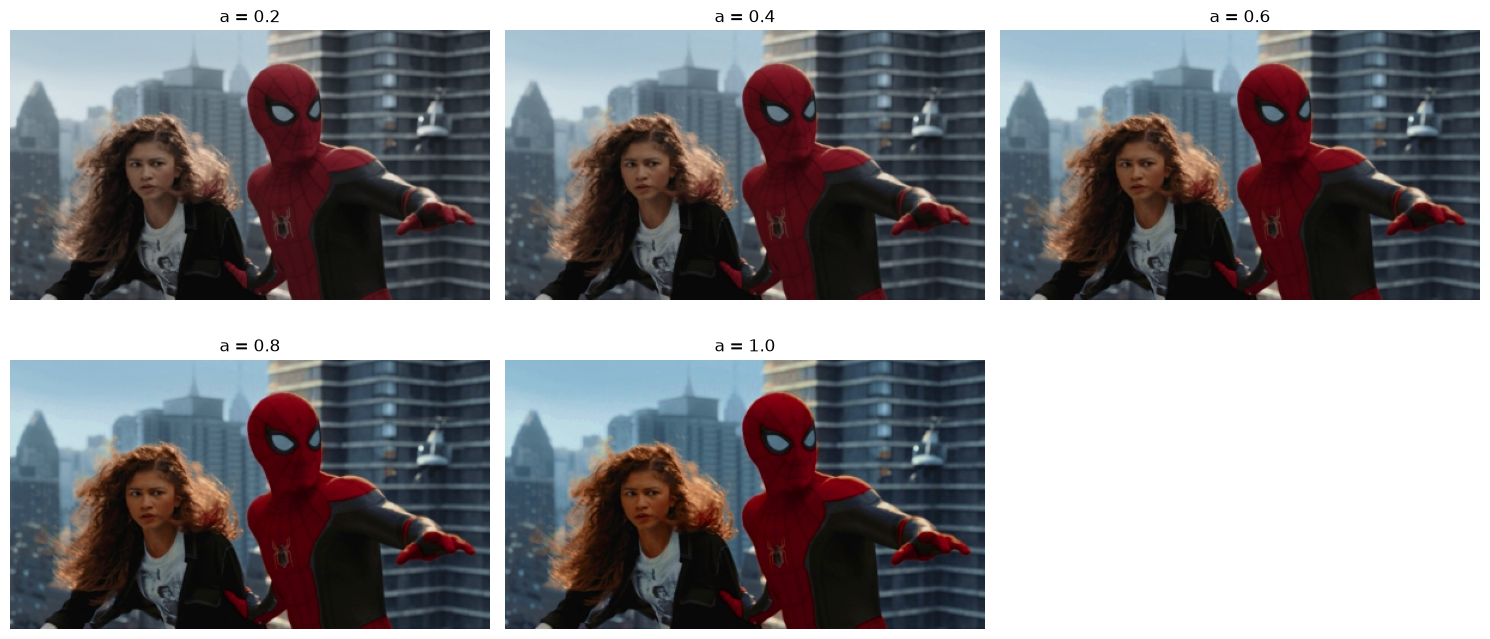

In [9]:
a_values = [0.2, 0.4, 0.6, 0.8, 1.0]

plt.figure(figsize=(15, 7))

for i, a_val in enumerate(a_values):
    S_corr = vibrance_transform(S, a_val)

    hsv_corr = cv.merge([H, S_corr, V])
    bgr_corr = cv.cvtColor(hsv_corr, cv.COLOR_HSV2BGR)
    rgb_corr = cv.cvtColor(bgr_corr, cv.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(rgb_corr)
    plt.title(f"a = {a_val}")
    plt.axis("off")

plt.tight_layout()
plt.show()

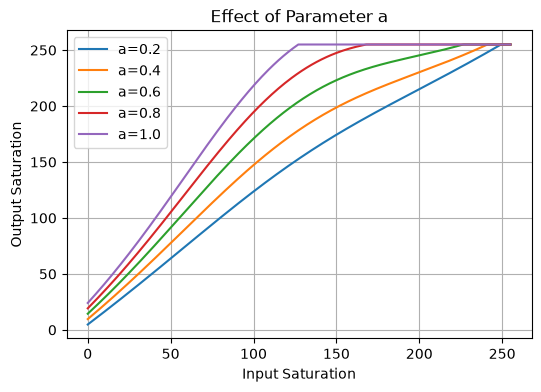

In [10]:
x = np.arange(256)

plt.figure(figsize=(6,4))

for a_val in a_values:
    y = x + a_val*128*np.exp(-((x-128)**2)/(2*70**2))
    plt.plot(x, np.clip(y,0,255), label=f"a={a_val}")

plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title("Effect of Parameter a")
plt.legend()
plt.grid()
plt.show()

**Discussion:** Increasing \(a\) increases the saturation boost, with the strongest
effect occurring around the middle saturation range. At \(a=0.2\) and \(a=0.4\),
the change is relatively mild, while \(a=0.8\) and \(a=1.0\) produce noticeably
stronger colors and some regions approach saturation clipping. A value of
\(a=0.6\) was selected as a compromise because it gives a clear improvement in
color vibrance while still keeping the image reasonably natural.

## Q5 — Histogram Equalization

Histogram equalization was implemented using the image histogram and its cumulative
distribution to spread the grayscale intensities over a wider range.

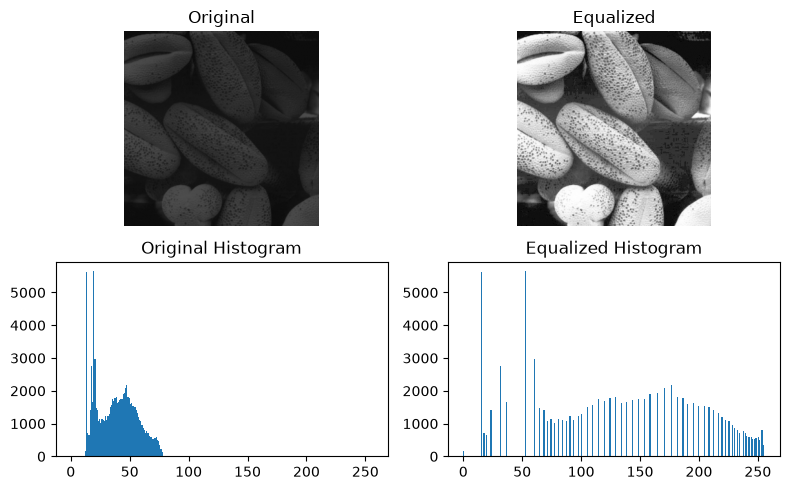

In [11]:
img_q5 = cv.imread(str(IMAGE_DIR/"q5_histogram.png"), cv.IMREAD_GRAYSCALE)

histogram = np.bincount(img_q5.ravel(), minlength=256)
cdf = np.cumsum(histogram)
cdf_min = cdf[cdf > 0][0]

equalization_map = np.clip(
    (cdf - cdf_min) / (img_q5.size - cdf_min) * 255,
    0, 255
).astype(np.uint8)

eq_q5 = equalization_map[img_q5]

fig,ax = plt.subplots(2,2,figsize=(8,5))

ax[0,0].imshow(img_q5,cmap="gray",vmin=0,vmax=255)
ax[0,0].set_title("Original")

ax[0,1].imshow(eq_q5,cmap="gray",vmin=0,vmax=255)
ax[0,1].set_title("Equalized")

ax[1,0].hist(img_q5.ravel(),bins=256, range=(0,256))
ax[1,0].set_title("Original Histogram")

ax[1,1].hist(eq_q5.ravel(),bins=256, range=(0,256))
ax[1,1].set_title("Equalized Histogram")

for a in ax[0]:
    a.axis("off")

plt.tight_layout()
plt.show()

**Discussion:** The original image uses only a limited part of the grayscale
range. Histogram equalization spreads the intensities over a wider range,
improving global contrast and making darker details easier to distinguish.
The resulting histogram is more widely distributed, although it is not perfectly uniform.

#### Q6 — Foreground Histogram Equalization

The saturation plane was used to separate the foreground from the gray background.
Histogram equalization was then applied only to the foreground pixels of the value
channel, while the background was kept unchanged.

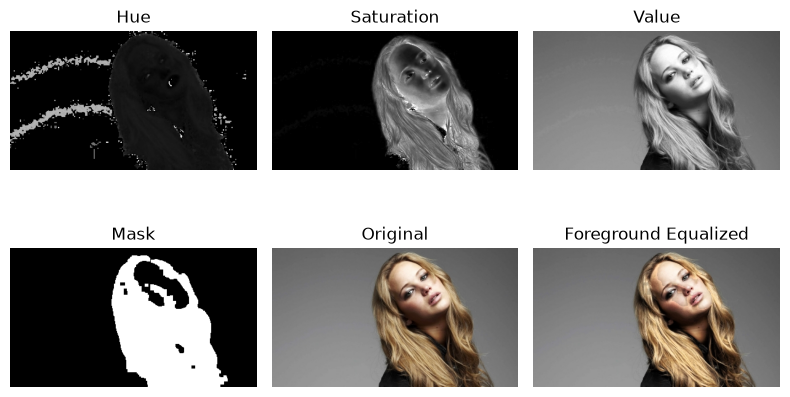

In [12]:
img_q6 = cv.imread(str(IMAGE_DIR/"q6_foreground.png"))
hsv = cv.cvtColor(img_q6, cv.COLOR_BGR2HSV)
H,S,V = cv.split(hsv)

_,mask = cv.threshold(S,80,255,cv.THRESH_BINARY)
k = np.ones((5,5),np.uint8)
mask = cv.morphologyEx(mask,cv.MORPH_CLOSE,k)
mask = cv.morphologyEx(mask,cv.MORPH_OPEN,k)

fg = V[mask==255]
hist = np.bincount(fg,minlength=256)
cdf = np.cumsum(hist); cmin = cdf[cdf>0][0]
lut = np.clip((cdf-cmin)/(fg.size-cmin)*255,0,255).astype(np.uint8)

Veq = V.copy()
Veq[mask==255] = lut[V[mask==255]]
out_q6 = cv.cvtColor(cv.merge([H,S,Veq]),cv.COLOR_HSV2RGB)

fig,ax = plt.subplots(2,3,figsize=(8,5))
for a,im,t in zip(ax.ravel(),[H,S,V,mask,cv.cvtColor(img_q6,cv.COLOR_BGR2RGB),out_q6],
                  ["Hue","Saturation","Value","Mask","Original","Foreground Equalized"]):
    a.imshow(im,cmap="gray" if im.ndim==2 else None); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

**Discussion:** The saturation plane gave a clear separation between the subject
and the gray background. Histogram equalization was calculated only from the
foreground pixels of the value channel, so the subject contrast was improved
while the background remained mostly unchanged.

#### Q7 — Sobel Filtering

Sobel filtering was carried out using OpenCV `filter2D`, a manual neighborhood
implementation, and the separable form of the Sobel kernel.

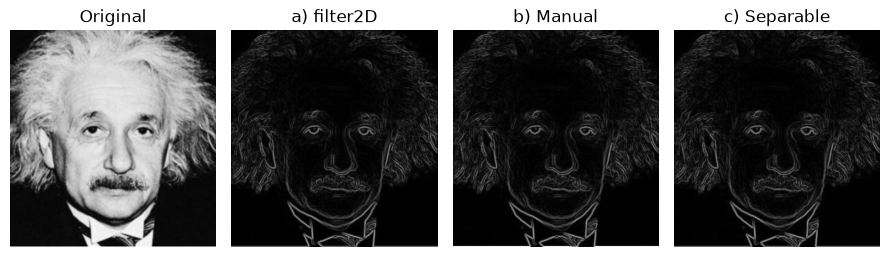

MSE manual: 1856.9062
MSE separable: 0.0


In [13]:
img_q7 = cv.imread(str(IMAGE_DIR/"q7_sobel.png"), cv.IMREAD_GRAYSCALE)
kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]],np.float32)
ky = kx.T

# a) OpenCV filter2D
gx1 = cv.filter2D(img_q7,cv.CV_32F,kx)
gy1 = cv.filter2D(img_q7,cv.CV_32F,ky)
mag1 = np.sqrt(gx1**2+gy1**2)

# b) Manual filtering
def my_filter(im,k):
    p=cv.copyMakeBorder(im.astype(np.float32),1,1,1,1,cv.BORDER_REFLECT)
    out=np.zeros_like(im,dtype=np.float32)
    for y in range(im.shape[0]):
        for x in range(im.shape[1]):
            out[y,x]=np.sum(p[y:y+3,x:x+3]*k)
    return out

gx2,gy2 = my_filter(img_q7,kx),my_filter(img_q7,ky)
mag2 = np.sqrt(gx2**2+gy2**2)

# c) Separable Sobel
s=np.array([[1],[2],[1]],np.float32); d=np.array([[-1,0,1]],np.float32)
gx3=cv.filter2D(cv.filter2D(img_q7.astype(np.float32),cv.CV_32F,s),cv.CV_32F,d)
gy3=cv.filter2D(cv.filter2D(img_q7.astype(np.float32),cv.CV_32F,d.T),cv.CV_32F,s.T)
mag3=np.sqrt(gx3**2+gy3**2)

fig,ax=plt.subplots(1,4,figsize=(9,3))
for a,im,t in zip(ax,[img_q7,mag1,mag2,mag3],
                  ["Original","a) filter2D","b) Manual","c) Separable"]):
    a.imshow(im,cmap="gray"); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

print("MSE manual:",np.mean((mag1-mag2)**2))
print("MSE separable:",np.mean((mag1-mag3)**2))

**Discussion:** All three methods produce similar Sobel edge responses. The manual
implementation performs the neighborhood multiplication directly, while the
separable method applies two 1D filters instead of one 2D filter, reducing the
number of operations.

#### Q8 — Image Zooming

Nearest-neighbor and bilinear interpolation were implemented for image zooming.
The supplied small images were enlarged by a factor of four and compared with
their corresponding original images using normalized SSD.

In [14]:
def zoom_image(im,s,method):
    h,w=im.shape[:2]
    out=np.zeros((int(h*s),int(w*s),3),dtype=np.uint8)
    for yo in range(out.shape[0]):
        for xo in range(out.shape[1]):
            y,x=yo/s,xo/s
            if method=="nearest":
                yi,xi=min(round(y),h-1),min(round(x),w-1)
                out[yo,xo]=im[yi,xi]
            else:
                y0,x0=int(np.floor(y)),int(np.floor(x))
                y1,x1=min(y0+1,h-1),min(x0+1,w-1)
                dy,dx=y-y0,x-x0
                p00,p10=im[y0,x0].astype(float),im[y0,x1].astype(float)
                p01,p11=im[y1,x0].astype(float),im[y1,x1].astype(float)
                out[yo,xo]=np.clip((1-dx)*(1-dy)*p00+dx*(1-dy)*p10+
                                   (1-dx)*dy*p01+dx*dy*p11,0,255)
    return out

def normalized_ssd(ref,test):
    h,w=min(ref.shape[0],test.shape[0]),min(ref.shape[1],test.shape[1])
    ref,test=ref[:h,:w].astype(float),test[:h,:w].astype(float)
    return np.sum((ref-test)**2)/np.sum(ref**2)

pairs=[("im01.png","im01small.png"),("im02.png","im02small.png"),
       ("im03.png","im03small.png"),("im04.jpg","im04small.jpg")]

for a,b in pairs:
    ref,small=cv.imread(str(IMAGE_DIR/a)),cv.imread(str(IMAGE_DIR/b))
    nn,bi=zoom_image(small,4,"nearest"),zoom_image(small,4,"bilinear")
    print(f"{a}: Nearest={normalized_ssd(ref,nn):.5f}, Bilinear={normalized_ssd(ref,bi):.5f}")

im01.png: Nearest=0.02259, Bilinear=0.01772
im02.png: Nearest=0.01024, Bilinear=0.00776
im03.png: Nearest=0.01472, Bilinear=0.01113
im04.jpg: Nearest=0.00960, Bilinear=0.00771


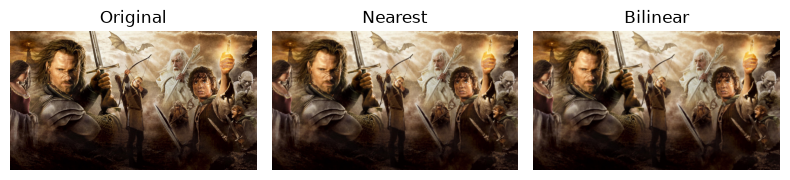

In [15]:
ref=cv.imread(str(IMAGE_DIR/"im01.png"))
small=cv.imread(str(IMAGE_DIR/"im01small.png"))
nn,bi=zoom_image(small,4,"nearest"),zoom_image(small,4,"bilinear")

fig,ax=plt.subplots(1,3,figsize=(8,3))
for a,im,t in zip(ax,[ref,nn,bi],["Original","Nearest","Bilinear"]):
    a.imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB)); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

**Discussion:** Nearest-neighbor interpolation gives a more block-like result,
while bilinear interpolation produces smoother transitions by using four
surrounding pixels. The lower NSSD values indicate which interpolation method
reconstructs the supplied original images more closely.

#### Q9 — Foreground Segmentation and Background Blur

GrabCut was used to separate the main flower from the background. The extracted
background was blurred and then recombined with the sharp foreground.

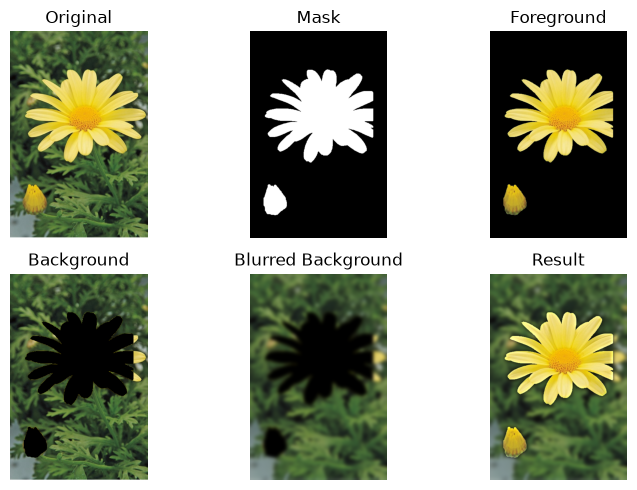

In [16]:
img_q9=cv.imread(str(IMAGE_DIR/"q9_flower.png"))
h,w=img_q9.shape[:2]

mask=np.zeros((h,w),np.uint8)
background=np.zeros((1,65),np.float64); foreground=np.zeros((1,65),np.float64)
rect=(int(.1*w),int(.05*h),int(.8*w),int(.85*h))

cv.grabCut(img_q9,mask,rect,background,foreground,5,cv.GC_INIT_WITH_RECT)

m=np.where((mask==cv.GC_FGD)|(mask==cv.GC_PR_FGD),255,0).astype(np.uint8)
fg_img=cv.bitwise_and(img_q9,img_q9,mask=m)
bg_mask=cv.bitwise_not(m)
bg_img=cv.bitwise_and(img_q9,img_q9,mask=bg_mask)

blur_bg=cv.GaussianBlur(bg_img,(31,31),0)
out_q9=cv.add(fg_img,blur_bg)

imgs=[img_q9,m,fg_img,bg_img,blur_bg,out_q9]
titles=["Original","Mask","Foreground","Background","Blurred Background","Result"]

fig,ax=plt.subplots(2,3,figsize=(8,5))
for a,im,t in zip(ax.ravel(),imgs,titles):
    if im.ndim==2: a.imshow(im,cmap="gray")
    else: a.imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB))
    a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

**Discussion:** GrabCut successfully separated the main flower from the
background. Blurring the extracted background makes the foreground more
prominent. A dark halo can appear near the flower boundary because the removed
foreground area contains zero-valued pixels, which are included in the Gaussian
averaging near the edge.

#### Q10 — Bilateral Filtering

Gaussian and bilateral filtering were compared. A custom bilateral filter was
also implemented and compared with OpenCV's `bilateralFilter`.

In [17]:
img_q10 = cv.imread(str(IMAGE_DIR/"q10_lake.png"))
ks, ss, sr = 5, 3, 30

gauss = cv.GaussianBlur(img_q10,(ks,ks),ss)
bil_cv = cv.bilateralFilter(img_q10,ks,sr,ss)

def bilateral(im, ks, ss, sr):
    r = ks//2
    padded = cv.copyMakeBorder(
        im.astype(float),
        r,r,r,r,
        cv.BORDER_REFLECT_101
    )
    output = np.zeros_like(im,float)
    Y,X = np.mgrid[-r:r+1,-r:r+1]
    spatial_weight = np.exp(
        -(X**2+Y**2)/(2*ss**2)
    )
    for y in range(im.shape[0]):
        for x in range(im.shape[1]):
            region = padded[y:y+ks,x:x+ks]
            center = padded[y+r,x+r]
            range_weight = np.exp(
                -np.sum((region-center)**2,axis=2)
                /(2*sr**2)
            )
            weights = spatial_weight * range_weight
            output[y,x] = np.sum(
                region*weights[:,:,None],
                axis=(0,1)
            ) / np.sum(weights)
    return np.clip(output,0,255).astype(np.uint8)

bil_my = bilateral(img_q10,ks,ss,sr)
mse = np.mean(
    (bil_cv.astype(float)-bil_my.astype(float))**2
)
psnr = 10*np.log10(255**2/mse)
print(f"MSE = {mse:.3f}")
print(f"PSNR = {psnr:.2f} dB")

MSE = 5.905
PSNR = 40.42 dB


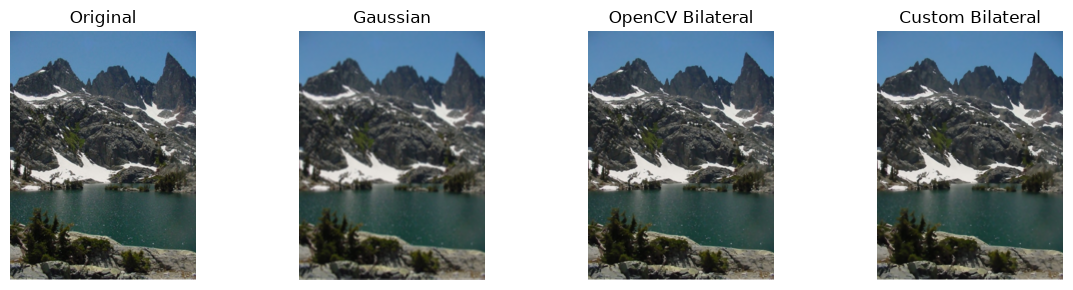

In [18]:
imgs=[img_q10,gauss,bil_cv,bil_my]
titles=["Original","Gaussian","OpenCV Bilateral","Custom Bilateral"]

plt.figure(figsize=(12,3))
for i,(im,t) in enumerate(zip(imgs,titles)):
    plt.subplot(1,4,i+1); plt.imshow(cv.cvtColor(im,cv.COLOR_BGR2RGB))
    plt.title(t); plt.axis("off")
plt.tight_layout(); plt.show()

### Discussion
Gaussian filtering smooths using only spatial distance, so edges are also blurred.
Bilateral filtering additionally considers intensity/color difference, allowing
smoothing while preserving strong edges. The custom result was compared with
OpenCV using MSE and PSNR; lower MSE and higher PSNR indicate closer agreement.